# Wilson (2014) Horizon Task — LLM Behavioral Analysis

**Paper:** Wilson, Geana, White, Ludvig & Cohen (2014). "Humans use directed and random exploration to solve the explore-exploit dilemma." *Journal of Experimental Psychology: General*, 143(6), 2074–2081.

**Dataset:** `marcelbinz/Psych-101` — `wilson2014humans/exp1.csv`

## Task Overview

A two-armed bandit task. Each "game" has:
- **4 forced-choice trials** (system specifies which option to play → information)
- **1 or 6 free-choice trials** (participant freely chooses — the "horizon")

### Key 2×2 Manipulation

| | Horizon 1 (H1) | Horizon 6 (H6) |
|---|---|---|
| **Equal info [2,2]** | 2 forced on each option | 2 forced on each option |
| **Unequal info [1,3]** | 1 forced on one, 3 on the other | 1 forced on one, 3 on the other |

### Human Signatures to Replicate

1. **Directed exploration** (information bonus): In *unequal* condition, humans choose the less-sampled (more uncertain) option *more* in H6 than H1 — the psychometric curve *shifts*.
2. **Random exploration** (noise): In *both* conditions, the psychometric curve *flattens* (shallower slope) in H6 vs H1.

## Notebook Structure

1. Setup & API Client  
2. Load & Explore Data  
3. Parse Transcripts → Structured DataFrame  
4. Human Behavioral Baselines  
5. LLM Experiment  
6. Comparative Analysis  
7. Discussion


## Section 1: Setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import re
import sys
import json
import math
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.special import expit
from scipy.stats import sem as scipy_sem

from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI
from datasets import load_dataset

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 20)

print("All imports successful.")


All imports successful.


In [2]:
# ── API Client ───────────────────────────────────────────────────────────
# Load .env from this directory or the demo subdirectory.
env_candidates = ['.env', 'CPSY-1950-Project-Demo/.env', '../CPSY-1950-Project-Demo/.env']
for ep in env_candidates:
    if Path(ep).exists():
        load_dotenv(ep)
        print(f"Loaded .env from: {ep}")
        break
else:
    print("WARNING: .env not found. Set OPENAI_API_KEY manually.")

BASE_URL = "https://litellm.ccv.brown.edu"

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=BASE_URL,
)
print(f"Client initialized at: {BASE_URL}")


Loaded .env from: .env
Client initialized at: https://litellm.ccv.brown.edu


In [3]:
# ── Available Models ─────────────────────────────────────────────────────
models_list = client.models.list()
available_ids = [m.id for m in models_list.data]
print("Available models:")
for mid in available_ids:
    print(f"  {mid}")

# Map short keys to actual API model names (try multiple name variants).
MODEL_CANDIDATES = {
    "llama": [
        "Llama-3.3-70B-Instruct",
        "meta-llama/Llama-3.3-70B-Instruct",
    ],
    "gpt": [
        "gpt-5.2",
    ],
}

MODELS = {}
for key, candidates in MODEL_CANDIDATES.items():
    for name in candidates:
        if name in available_ids:
            MODELS[key] = name
            print(f"  Found '{key}' → {name}")
            break
    if key not in MODELS:
        MODELS[key] = candidates[0]
        print(f"  WARNING: '{key}' not in model list; using {candidates[0]} (may fail)")

print(f"\nModels to use: {MODELS}")


Available models:
  gemini-3-flash-preview
  claude-sonnet-4-5
  gpt-5.4
  gpt-oss
  Llama-3.3-70B-Instruct
  Mistral-Large-3
  gpt-5.2
  gpt-5.2-codex
  gemini-2.5-pro
  gemini-3.1-flash-lite-preview
  Found 'llama' → Llama-3.3-70B-Instruct
  Found 'gpt' → gpt-5.2

Models to use: {'llama': 'Llama-3.3-70B-Instruct', 'gpt': 'gpt-5.2'}


## Section 2: Load and Explore the Wilson 2014 Dataset

Each record in Psych-101 is one participant's full session. The `text` field is a natural-language transcript where human choices are marked with `<<choice>>` delimiters.


In [4]:
print("Loading Psych-101 (cached after first download)...")
dataset = load_dataset("marcelbinz/Psych-101", split="train")

wilson_data = dataset.filter(
    lambda x: "wilson2014" in x["experiment"].lower()
)

experiments = sorted(set(wilson_data['experiment']))
print(f"Found {len(wilson_data)} records:")
for e in experiments:
    n = sum(1 for x in wilson_data if x['experiment'] == e)
    print(f"  {e}: {n} participants")


Loading Psych-101 (cached after first download)...


Found 221 records:
  wilson2014humans/exp1.csv: 27 participants
  wilson2014humans/exp2.csv: 7 participants
  wilson2014humans/exp3.csv: 68 participants
  wilson2014humans/exp4.csv: 80 participants
  wilson2014humans/exp5.csv: 39 participants


In [5]:
# ── Inspect raw text format ───────────────────────────────────────────────
example = wilson_data[0]
text0 = example['text']

print(f"Experiment: {example['experiment']}")
print(f"Total characters: {len(text0)}")
print()
print("="*60)
print("RAW TEXT (first 3500 chars):")
print("="*60)
print(text0[:3500])


Experiment: wilson2014humans/exp1.csv
Total characters: 116671

RAW TEXT (first 3500 chars):
You are participating in multiple games involving two slot machines, labeled C and A.
The two slot machines are different across different games.
Each time you choose a slot machine, you get some points.
You choose a slot machine by pressing the corresponding key.
Each slot machine tends to pay out about the same amount of points on average.
Your goal is to choose the slot machines that will give you the most points across the experiment.
The first 4 trials in each game are instructed trials where you will be told which slot machine to choose.
After these instructed trials, you will have the freedom to choose for either 1 or 6 trials.

Game 1. There are 5 trials in this game.
You are instructed to press A and get 66 points.
You are instructed to press A and get 80 points.
You are instructed to press C and get 29 points.
You are instructed to press A and get 75 points.
You press <<A>> and get 81

In [6]:
# ── Inspect choice structure ──────────────────────────────────────────────
choices0 = re.findall(r'<<([^>]+)>>', text0)
unique_labels = sorted(set(choices0))

print(f"Total <<choice>> markers in first record: {len(choices0)}")
print(f"Unique choice labels found: {unique_labels}")
print(f"\nFirst 40 choices: {choices0[:40]}")

# Context around first 8 decisions
print("\n" + "="*60)
print("Context around first 8 <<choice>> markers:")
print("="*60)
for i, m in enumerate(list(re.finditer(r'<<([^>]+)>>', text0))[:8]):
    ctx_start = max(0, m.start() - 160)
    ctx_end   = min(len(text0), m.end() + 100)
    snippet   = text0[ctx_start:ctx_end].replace('\n', ' | ')
    print(f"\n[{i+1}] <<{m.group(1)}>>")
    print(f"  ...{snippet}...")


Total <<choice>> markers in first record: 1120
Unique choice labels found: ['A', 'C']

First 40 choices: ['A', 'C', 'A', 'A', 'A', 'A', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'A', 'C', 'A', 'C', 'A', 'A', 'A', 'C', 'A', 'A', 'C', 'A', 'A', 'C', 'A', 'C', 'A', 'C', 'A', 'C', 'C', 'C', 'C']

Context around first 8 <<choice>> markers:

[1] <<A>>
  ...s. | You are instructed to press A and get 80 points. | You are instructed to press C and get 29 points. | You are instructed to press A and get 75 points. | You press <<A>> and get 81 points. |  | Game 2. There are 10 trials in this game. | You are instructed to press A and get...

[2] <<C>>
  ...s. | You are instructed to press A and get 50 points. | You are instructed to press C and get 51 points. | You are instructed to press A and get 64 points. | You press <<C>> and get 42 points. | You press <<A>> and get 54 points. | You press <<A>> and get 64 points. | You press ...

[3] <<A>>
  ...d get 50 points. | You are instructe

In [7]:
# ── Identify game boundaries ──────────────────────────────────────────────
# Look for "Game N" / "Round N" / block markers
game_markers = re.findall(r'(?:game|round|block|trial\s*set)\s*\d+', text0, re.IGNORECASE)
print(f"Game/Round markers in first record: {game_markers[:30]}")

total_choices = len(choices0)
print(f"\nTotal choices: {total_choices}")
print(f"  If all H1 (5 per game): {total_choices/5:.1f} games")
print(f"  If all H6 (10 per game): {total_choices/10:.1f} games")

# Look at text near the 5th and 6th choices (likely a game boundary)
all_m = list(re.finditer(r'<<([^>]+)>>', text0))
if len(all_m) > 6:
    region = text0[all_m[3].end():all_m[6].start() + 300]
    print(f"\nText spanning choices 4–7 (possible game boundary):")
    print(region[:600])


Game/Round markers in first record: ['Game 1', 'Game 2', 'Game 3', 'Game 4', 'Game 5', 'Game 6', 'Game 7', 'Game 8', 'Game 9', 'Game 10', 'Game 11', 'Game 12', 'Game 13', 'Game 14', 'Game 15', 'Game 16', 'Game 17', 'Game 18', 'Game 19', 'Game 20', 'Game 21', 'Game 22', 'Game 23', 'Game 24', 'Game 25', 'Game 26', 'Game 27', 'Game 28', 'Game 29', 'Game 30']

Total choices: 1120
  If all H1 (5 per game): 224.0 games
  If all H6 (10 per game): 112.0 games

Text spanning choices 4–7 (possible game boundary):
 and get 64 points.
You press <<A>> and get 64 points.
You press <<A>> and get 57 points.
You press <<C>> and get 55 points.

Game 3. There are 10 trials in this game.
You are instructed to press A and get 31 points.
You are instructed to press C and get 43 points.
You are instructed to press A and get 26 points.
You are instructed to press C and get 36 points.
You press <<C>> and get 26 points.
Y


## Section 3: Parsing the Transcripts

We parse each participant's session into per-game records.

**Parsing strategy:**
1. Extract all `<<choice>>` steps with their prefix and suffix text.
2. Detect game boundaries from text markers (`"Game N:"`, `"Round N:"`, etc.); fall back to positional grouping (Wilson 2014 always has exactly 4 forced trials per game, so games contain 5 or 10 steps total).
3. Classify forced vs. free trials: keyword detection (`"forced"`, `"must"`, …) as primary; positional rule (first 4 = forced) as fallback.
4. Extract rewards from the suffix text following each choice.
5. Infer info condition from forced-trial allocation: [1,3] → **unequal**, [2,2] → **equal**.
6. Infer horizon from number of free trials: 1 → **H1**, 6 → **H6**.


In [8]:
# ── Parsing helper functions (corrected for actual data format) ─────────────
#
# Format discovered by inspection:
#   Forced trials: "You are instructed to press X and get N points."  (NO <<>> marker)
#   Free trials:   "You press <<X>> and get N points."                (HAS <<>> marker)
#   Game headers:  "Game N. There are 5/10 trials in this game."
#
# This means extract_steps_full() returns ONLY free-choice steps.
# Forced-trial data lives in the prefix text of the first free step of each game.

def extract_steps_full(text):
    """
    Extract all <<choice>> steps.
    Each step dict: prefix (text before <<), decision, suffix (text until next <<).
    """
    pattern = r'<<([^>]+)>>'
    matches = list(re.finditer(pattern, text))
    steps, prev_end = [], 0
    for i, m in enumerate(matches):
        start, end = m.span()
        decision = m.group(1).strip()
        if decision.lower() == 'nan':
            prev_end = end
            continue
        prefix = text[prev_end:start]
        next_start = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        suffix = text[end:next_start]
        steps.append({'prefix': prefix, 'decision': decision,
                      'suffix': suffix, 'start_pos': start, 'end_pos': end})
        prev_end = end
    return steps


def extract_reward(text_snippet):
    """Parse the first integer reward from text like ' and get 81 points.'"""
    m = re.search(r'(\d+)\s*points?', text_snippet, re.IGNORECASE)
    return int(m.group(1)) if m else None


def find_game_boundaries(steps):
    """
    Return step indices where a new game begins (i.e. whose prefix contains a
    game-header line like 'Game N. There are M trials in this game.').
    """
    boundaries = []
    for i, s in enumerate(steps):
        if re.search(r'\bGame\s+\d+', s['prefix'], re.IGNORECASE):
            boundaries.append(i)
    # Fallback: every step starts a game (shouldn't happen with Wilson 2014)
    return boundaries if boundaries else [0]


def parse_game(game_steps, participant_id, game_id, opt_A, opt_B):
    """
    Parse one game whose *free-choice* steps are in game_steps.

    Forced-trial information is extracted from the prefix of the first free step,
    which contains lines like:
        'You are instructed to press A and get 66 points.'
    """
    if not game_steps:
        return None

    horizon = len(game_steps)
    if horizon not in [1, 6]:
        return None

    first_prefix = game_steps[0]['prefix']

    # ── Extract forced trials from prefix ────────────────────────────────────
    # Pattern: "instructed to press X and get N points"
    forced_matches = re.findall(
        r'instructed to press\s+(\S+)\s+and get\s+(\d+)\s+points',
        first_prefix, re.IGNORECASE
    )
    if len(forced_matches) != 4:
        return None     # malformed game — skip

    forced_choices = [(m[0], int(m[1])) for m in forced_matches]  # [(label, reward), ...]

    # ── Verify total trial count matches horizon ──────────────────────────────
    header = re.search(r'There are (\d+) trials', first_prefix, re.IGNORECASE)
    if header:
        expected = int(header.group(1))
        if expected not in [5, 10]:
            return None
        if expected - 4 != horizon:
            return None     # trial count inconsistent with free steps found

    # ── Info condition from forced-trial allocation ───────────────────────────
    n_A = sum(1 for c, _ in forced_choices if c == opt_A)
    n_B = sum(1 for c, _ in forced_choices if c == opt_B)
    counts = tuple(sorted([n_A, n_B]))

    if counts == (1, 3):
        info_condition = 'unequal'
        more_inf = opt_A if n_A == 1 else opt_B
        less_inf = opt_B if n_A == 1 else opt_A
    elif counts == (2, 2):
        info_condition = 'equal'
        more_inf, less_inf = opt_A, opt_B
    else:
        return None

    # ── Mean rewards from forced trials ──────────────────────────────────────
    rewards_more = [r for c, r in forced_choices if c == more_inf]
    rewards_less = [r for c, r in forced_choices if c == less_inf]
    mean_more = float(np.mean(rewards_more)) if rewards_more else np.nan
    mean_less = float(np.mean(rewards_less)) if rewards_less else np.nan
    mean_diff = mean_more - mean_less

    # ── Free-choice data ──────────────────────────────────────────────────────
    first_choice = game_steps[0]['decision']
    free_choices  = [s['decision'] for s in game_steps]
    free_rewards  = [extract_reward(s['suffix']) for s in game_steps]

    # Prompt for model: everything up to (and including) opening << of first free choice
    prompt_to_first_free = first_prefix + "<<"

    return {
        'participant_id':        participant_id,
        'game_id':               game_id,
        'horizon':               horizon,
        'info_condition':        info_condition,
        'opt_A':                 opt_A,
        'opt_B':                 opt_B,
        'more_informative':      more_inf,
        'less_informative':      less_inf,
        'n_A_forced':            n_A,
        'n_B_forced':            n_B,
        'mean_more_inf':         mean_more,
        'mean_less_inf':         mean_less,
        'mean_diff':             mean_diff,
        'first_free_choice':     first_choice,
        'chose_more_informative': int(first_choice == more_inf),
        'free_choices':          free_choices,
        'free_rewards':          free_rewards,
        'n_free_trials':         horizon,
        'prompt_to_first_free':  prompt_to_first_free,
        '_free_steps':           game_steps,
    }


def parse_participant(text, participant_id):
    """Parse a full participant transcript into a list of game records."""
    steps = extract_steps_full(text)
    if not steps:
        return []

    labels = sorted(set(s['decision'] for s in steps))
    if len(labels) != 2:
        return []
    opt_A, opt_B = labels[0], labels[1]

    boundaries = find_game_boundaries(steps)
    games = []
    for gi, start in enumerate(boundaries):
        end = boundaries[gi + 1] if gi + 1 < len(boundaries) else len(steps)
        rec = parse_game(steps[start:end], participant_id, gi, opt_A, opt_B)
        if rec is not None:
            games.append(rec)
    return games


print("Parsing helpers defined.")
print()
# Quick smoke test on one participant
_test = parse_participant(wilson_data[0]['text'], 0)
print(f"Smoke test on participant 0: {len(_test)} games parsed")
if _test:
    from collections import Counter
    print("  Horizons:   ", Counter(g['horizon'] for g in _test))
    print("  Info conds: ", Counter(g['info_condition'] for g in _test))
    g0 = _test[0]
    print(f"  Game 0: H{g0['horizon']}, {g0['info_condition']}, "
          f"mean_diff={g0['mean_diff']:.1f}, first_choice={g0['first_free_choice']}")


Parsing helpers defined.

Smoke test on participant 0: 320 games parsed
  Horizons:    Counter({1: 160, 6: 160})
  Info conds:  Counter({'unequal': 160, 'equal': 160})
  Game 0: H1, unequal, mean_diff=-44.7, first_choice=A


In [9]:
# ── Parse all participants ────────────────────────────────────────────────
all_games = []
n_failed = 0

for pid, example in enumerate(tqdm(wilson_data, desc="Parsing participants")):
    games = parse_participant(example['text'], pid)
    all_games.extend(games)
    if not games:
        n_failed += 1

print(f"\nParsed {len(all_games)} games from "
      f"{len(wilson_data) - n_failed}/{len(wilson_data)} participants.")
print(f"Failed/skipped: {n_failed}")

# Quick sanity check
if all_games:
    from collections import Counter
    h_counts = Counter(g['horizon'] for g in all_games)
    i_counts = Counter(g['info_condition'] for g in all_games)
    print(f"\nHorizon:        {dict(h_counts)}")
    print(f"Info condition: {dict(i_counts)}")
    # Cross-tabulation
    cross = Counter((g['horizon'], g['info_condition']) for g in all_games)
    print("\nCross-tabulation (horizon, info_condition):")
    for (h, ic), n in sorted(cross.items()):
        print(f"  H{h} × {ic}: {n}")


Parsing participants: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [00:00<00:00, 322.30it/s]


Parsed 39675 games from 221/221 participants.
Failed/skipped: 0

Horizon:        {1: 19835, 6: 19840}
Info condition: {'unequal': 19842, 'equal': 19833}

Cross-tabulation (horizon, info_condition):
  H1 × equal: 9918
  H1 × unequal: 9917
  H6 × equal: 9915
  H6 × unequal: 9925


In [10]:
# ── Build flat per-game DataFrame ─────────────────────────────────────────
BIN_WIDTH = 4   # reward-point bins for psychometric curve

records = []
for g in all_games:
    records.append({
        'participant_id':        g['participant_id'],
        'game_id':               g['game_id'],
        'horizon':               g['horizon'],
        'info_condition':        g['info_condition'],
        'more_informative':      g['more_informative'],
        'less_informative':      g['less_informative'],
        'mean_diff':             g['mean_diff'],
        'first_free_choice':     g['first_free_choice'],
        'chose_more_informative': g['chose_more_informative'],
        'n_free_trials':         g['n_free_trials'],
    })

df = pd.DataFrame(records)
df = df.dropna(subset=['mean_diff'])
df['mean_diff_bin'] = (df['mean_diff'] / BIN_WIDTH).round() * BIN_WIDTH

print(f"DataFrame shape: {df.shape}")
print()
print(df.groupby(['horizon', 'info_condition']).agg(
    n_games=('chose_more_informative', 'count'),
    p_chose_more=('chose_more_informative', 'mean'),
    mean_diff_range=('mean_diff', lambda x: f"[{x.min():.1f}, {x.max():.1f}]")
).to_string())
df.head(6)


DataFrame shape: (39675, 11)

                        n_games  p_chose_more mean_diff_range
horizon info_condition                                       
1       equal              9918      0.499899   [-50.5, 51.0]
        unequal            9917      0.491782   [-53.3, 51.7]
6       equal              9915      0.510842   [-54.5, 53.0]
        unequal            9925      0.566448   [-54.7, 56.0]


,participant_id,game_id,horizon,info_condition,more_informative,less_informative,mean_diff,first_free_choice,chose_more_informative,n_free_trials,mean_diff_bin
0,0,0,1,unequal,C,A,-44.666667,A,0,1,-44.0
1,0,1,6,unequal,C,A,-10.000000,C,1,6,-8.0
2,0,2,6,equal,A,C,-11.000000,C,0,6,-12.0
3,0,3,6,equal,A,C,-4.500000,C,0,6,-4.0
4,0,4,6,equal,A,C,26.500000,A,1,6,28.0
5,0,5,6,unequal,A,C,-9.000000,A,1,6,-8.0


In [11]:
# ── Validate: inspect a few example games ────────────────────────────────
print("=== EXAMPLE RECORDS (one per condition cell) ===\n")
for (ic, h) in [('equal',1),('equal',6),('unequal',1),('unequal',6)]:
    row = df[(df['info_condition']==ic) & (df['horizon']==h)].head(1)
    if len(row):
        r = row.iloc[0]
        print(f"  {ic} / H{h}:  mean_diff={r['mean_diff']:.1f}  "
              f"choice={r['first_free_choice']}  "
              f"chose_more_inf={r['chose_more_informative']}")

# Inspect example prompt for one game
example_game = next(
    g for g in all_games
    if g['info_condition'] == 'unequal' and g['horizon'] == 6
)
print("\n=== EXAMPLE PROMPT (unequal, H6) — last 1500 chars ===")
print(example_game['prompt_to_first_free'][-1500:])
print("<<  ← model completes here")


=== EXAMPLE RECORDS (one per condition cell) ===

  equal / H1:  mean_diff=27.5  choice=C  chose_more_inf=0
  equal / H6:  mean_diff=-11.0  choice=C  chose_more_inf=0
  unequal / H1:  mean_diff=-44.7  choice=A  chose_more_inf=0
  unequal / H6:  mean_diff=-10.0  choice=C  chose_more_inf=1

=== EXAMPLE PROMPT (unequal, H6) — last 1500 chars ===
 and get 81 points.

Game 2. There are 10 trials in this game.
You are instructed to press A and get 69 points.
You are instructed to press A and get 50 points.
You are instructed to press C and get 51 points.
You are instructed to press A and get 64 points.
You press <<
<<  ← model completes here


## Section 4: Human Behavioral Baselines

We compute **psychometric choice curves**: for each (horizon × info_condition) cell, we plot
P(chose more-informative option) as a function of `mean_diff`
(= mean reward of more-informative option minus mean reward of less-informative option,
computed from forced-trial observations).

A **logistic function** is fit to each curve:

$$P(\text{choose more-informative}) = \sigma\!\left(\frac{x - \mu}{\beta}\right)$$

- $\mu$ = indifference point (information bonus when $\mu < 0$: model favors uncertain option even when it looks slightly worse)
- $\beta$ = inverse slope = decision noise proxy (higher $\beta$ → shallower curve → more random exploration)


In [12]:
# ── Psychometric utility functions ───────────────────────────────────────

def binned_psychometric(df_sub, x_col='mean_diff_bin',
                         y_col='chose_more_informative', min_n=5):
    """Compute mean ± SEM of y within x bins. Returns a DataFrame."""
    g = df_sub.groupby(x_col)[y_col].agg(['mean', 'count', 'sem']).reset_index()
    g.columns = ['x', 'p_chose', 'n', 'sem']
    return g[g['n'] >= min_n].copy()


def logistic(x, mu, beta):
    """Logistic psychometric function. beta > 0 is the inverse slope."""
    return expit((x - mu) / beta)


def fit_logistic(curve_df, p0=(0.0, 8.0)):
    """Fit logistic to binned psychometric data. Returns (mu, beta) or None."""
    if len(curve_df) < 3:
        return None
    try:
        popt, _ = curve_fit(
            logistic, curve_df['x'].values, curve_df['p_chose'].values,
            p0=p0, bounds=([-40, 0.5], [40, 80]), maxfev=5000
        )
        return tuple(popt)
    except Exception:
        return None


print("Psychometric utility functions defined.")


Psychometric utility functions defined.


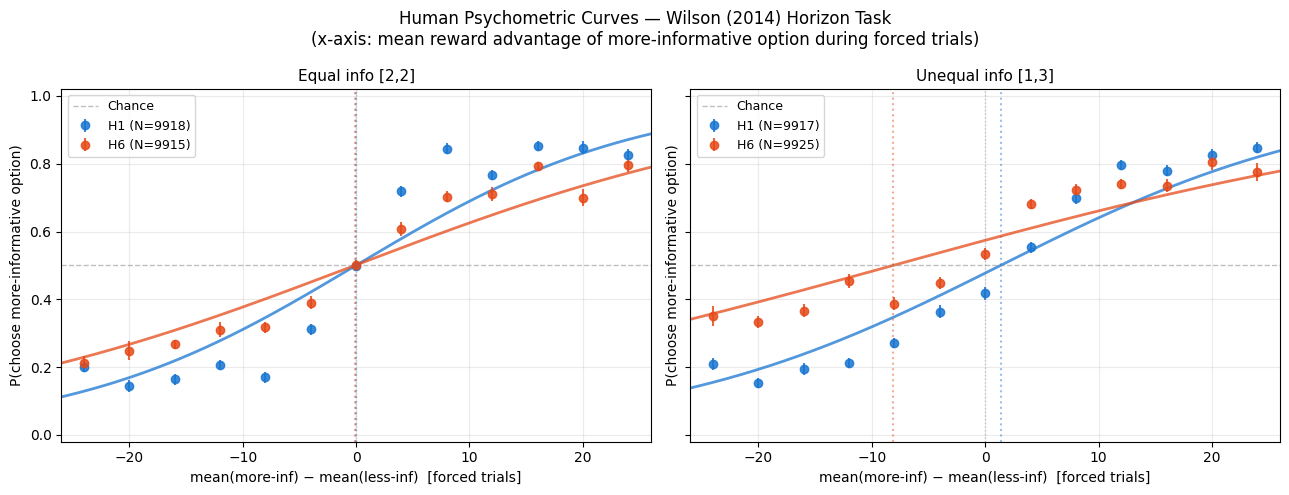

Saved: human_psychometric_curves.png


In [13]:
# ── Plot human psychometric curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle(
    "Human Psychometric Curves — Wilson (2014) Horizon Task\n"
    "(x-axis: mean reward advantage of more-informative option during forced trials)",
    fontsize=12
)

H_COLORS = {1: '#1976D2', 6: '#E64A19'}
x_fine = np.linspace(-28, 28, 400)

human_fits = {}   # (info_condition, horizon) → (mu, beta)

for ax, info_cond, title_tag in zip(
        axes,
        ['equal', 'unequal'],
        ['Equal info [2,2]', 'Unequal info [1,3]']):

    for horizon in [1, 6]:
        sub = df[(df['info_condition'] == info_cond) &
                 (df['horizon'] == horizon)]
        if len(sub) < 5:
            continue

        curve = binned_psychometric(sub)
        params = fit_logistic(curve)

        ax.errorbar(
            curve['x'], curve['p_chose'], yerr=curve['sem'],
            fmt='o', color=H_COLORS[horizon], alpha=0.85, markersize=6,
            label=f'H{horizon} (N={len(sub)})'
        )

        if params:
            mu, beta = params
            human_fits[(info_cond, horizon)] = (mu, beta)
            ax.plot(x_fine, logistic(x_fine, mu, beta),
                    '-', color=H_COLORS[horizon], lw=2, alpha=0.75)
            ax.axvline(mu, color=H_COLORS[horizon], ls=':', alpha=0.45)

    ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='Chance')
    ax.axvline(0,   color='gray', ls=':',  lw=1, alpha=0.4)
    ax.set_xlim(-26, 26)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("mean(more-inf) − mean(less-inf)  [forced trials]", fontsize=10)
    ax.set_ylabel("P(choose more-informative option)", fontsize=10)
    ax.set_title(title_tag, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('human_psychometric_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: human_psychometric_curves.png")


In [14]:
# ── Human behavioral signatures ──────────────────────────────────────────
print("="*60)
print("HUMAN BEHAVIORAL SIGNATURES SUMMARY")
print("="*60)

print("\n1. DIRECTED EXPLORATION — information bonus")
print("   P(chose more-informative | mean_diff=0) > 0.5 in UNEQUAL condition")
print("   and should INCREASE from H1 to H6 (only in UNEQUAL)\n")
for ic in ['equal', 'unequal']:
    vals = {}
    for h in [1, 6]:
        if (ic, h) in human_fits:
            mu, beta = human_fits[(ic, h)]
            vals[h] = float(logistic(0, mu, beta))
    if vals:
        delta = vals.get(6, np.nan) - vals.get(1, np.nan)
        for h, p in vals.items():
            print(f"  {ic} H{h}: P(more-inf | diff=0) = {p:.3f}")
        print(f"   Δ(H6−H1) = {delta:+.3f}  {'✓ info bonus increases' if delta > 0.02 else '✗ no clear increase'}\n")

print("\n2. RANDOM EXPLORATION — decision noise (inverse slope β)")
print("   β should INCREASE from H1 to H6 in BOTH conditions\n")
for ic in ['equal', 'unequal']:
    betas = {}
    for h in [1, 6]:
        if (ic, h) in human_fits:
            betas[h] = human_fits[(ic, h)][1]
    if 1 in betas and 6 in betas:
        pct = (betas[6] - betas[1]) / betas[1] * 100
        print(f"  {ic}:  β_H1={betas[1]:.2f}, β_H6={betas[6]:.2f}  "
              f"({pct:+.1f}%)  {'✓ noise increases' if pct > 5 else '✗ unclear'}")


HUMAN BEHAVIORAL SIGNATURES SUMMARY

1. DIRECTED EXPLORATION — information bonus
   P(chose more-informative | mean_diff=0) > 0.5 in UNEQUAL condition
   and should INCREASE from H1 to H6 (only in UNEQUAL)

  equal H1: P(more-inf | diff=0) = 0.500
  equal H6: P(more-inf | diff=0) = 0.501
   Δ(H6−H1) = +0.001  ✗ no clear increase

  unequal H1: P(more-inf | diff=0) = 0.477
  unequal H6: P(more-inf | diff=0) = 0.574
   Δ(H6−H1) = +0.097  ✓ info bonus increases


2. RANDOM EXPLORATION — decision noise (inverse slope β)
   β should INCREASE from H1 to H6 in BOTH conditions

  equal:  β_H1=12.56, β_H6=19.71  (+57.0%)  ✓ noise increases
  unequal:  β_H1=14.96, β_H6=27.16  (+81.5%)  ✓ noise increases


## Section 5: LLM Experiment

### Prompting Strategy

For each game we take the Psych-101 transcript verbatim up through the forced trials and append the
text leading to the first free-choice decision, stopping just before the human's `<<` response.
We then append `<<` to cue the model to complete with its choice:

```
<cover story> <forced trial 1> <forced trial 2> <forced trial 3> <forced trial 4>
<first free trial context><<    ← model completes here
```

An instruction hint appended to the prompt encourages a valid short response.

**Logprobs**: We request `top_logprobs=5` at the first generated token. Because
Wilson 2014 option labels are typically short tokens (`"1"` / `"2"`, or `"F"` / `"J"`),
the discriminating token appears directly in the first position. We then normalize:

$$P(A \mid \text{valid}) = \frac{e^{\ell_A}}{e^{\ell_A} + e^{\ell_B}}$$

This gives a probability estimate suitable for both the psychometric curve and NLL scoring.

**Note on temperature**: No explicit temperature is set (API default). This matches the
approach used in the demo notebook and ensures logprobs reflect the model's natural distribution.

**Sequential H6 analysis** (Section 6D): For a subset of H6 games, we query all 6 free-choice
steps using the *human's* actual history (i.e., scoring the model's alignment with each human
choice in sequence). This is the NLL alignment approach, not a free rollout.


In [15]:
# ── API call with logprobs ────────────────────────────────────────────────

INSTRUCTION_HINT = ("(Respond with only the option label — a single token — "
                    "that best fits the experimental context.)")


def query_model(client, model_name, prompt_text,
                max_tokens=15, max_retries=3, retry_delay=2.0):
    """
    Query the LiteLLM API with logprobs=True, top_logprobs=5.
    Returns the response object or None on failure.
    """
    for attempt in range(max_retries):
        try:
            return client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user",
                           "content": prompt_text + INSTRUCTION_HINT}],
                logprobs=True,
                top_logprobs=5,
                max_tokens=max_tokens,
                reasoning_effort=None,
            )
        except Exception as exc:
            wait = retry_delay * (attempt + 1)
            if attempt < max_retries - 1:
                print(f"  API error (attempt {attempt+1}): {exc}. Retrying in {wait:.0f}s…")
                time.sleep(wait)
            else:
                print(f"  API failed after {max_retries} attempts: {exc}")
                return None


def extract_choice_probs(response, opt_A, opt_B):
    """
    Extract P(opt_A) and P(opt_B) from top_logprobs of the first generated token.

    Handles:
    - Single-token labels: '1'/'2', 'F'/'J', 'left'/'right' (checked at token 0)
    - Multi-token labels sharing a common prefix, e.g. 'Machine 1'/'Machine 2'
      (common prefix at token 0; discriminating digit at token 1)

    Returns a dict or None.
    """
    if response is None:
        return None
    try:
        lp_content = response.choices[0].logprobs.content
        if not lp_content:
            return None

        # ── Determine common prefix length of opt_A / opt_B
        common_len = 0
        for ca, cb in zip(opt_A, opt_B):
            if ca == cb:
                common_len += 1
            else:
                break
        disc_A = opt_A[common_len:].strip()
        disc_B = opt_B[common_len:].strip()

        # ── Choose which token position to inspect
        if common_len > 0 and len(lp_content) > 1:
            # Options share a prefix token — look at second token
            tok_data = lp_content[1]
        else:
            # Options distinguished at first token
            tok_data  = lp_content[0]
            disc_A, disc_B = opt_A, opt_B

        generated_tok = tok_data.token.strip()
        tok_lp = {e.token.strip(): e.logprob for e in (tok_data.top_logprobs or [])}
        tok_lp[generated_tok] = tok_data.logprob

        # Case-insensitive lookup helper
        def get_lp(label):
            if label in tok_lp:
                return tok_lp[label]
            ll = label.lower()
            for k, v in tok_lp.items():
                if k.lower() == ll:
                    return v
            return None

        lp_A = get_lp(disc_A)
        lp_B = get_lp(disc_B)

        if lp_A is None or lp_B is None:
            # Fall back: infer from generated text
            gen = response.choices[0].message.content.strip()
            if gen.lower().startswith(opt_A.lower()):
                return {'p_A': 1.0, 'p_B': 0.0,
                        'generated': gen, 'note': 'fallback_generation'}
            if gen.lower().startswith(opt_B.lower()):
                return {'p_A': 0.0, 'p_B': 1.0,
                        'generated': gen, 'note': 'fallback_generation'}
            return None

        # Normalize over the two valid options
        p_A_raw = math.exp(lp_A)
        p_B_raw = math.exp(lp_B)
        total   = p_A_raw + p_B_raw
        return {
            'p_A': p_A_raw / total,
            'p_B': p_B_raw / total,
            'lp_A': lp_A,
            'lp_B': lp_B,
            'generated': generated_tok,
            'all_tok_lp': tok_lp,
        }
    except Exception as exc:
        print(f"  logprob extraction error: {exc}")
        return None


def choice_nll(probs_dict, human_choice, opt_A, opt_B):
    """NLL of the human choice given model probabilities."""
    if probs_dict is None:
        return None
    p = probs_dict['p_A'] if human_choice == opt_A else probs_dict['p_B']
    return -math.log(max(p, 1e-9))


print("API call and logprob functions defined.")


API call and logprob functions defined.


In [16]:
# ── Validation run: 5 games ───────────────────────────────────────────────
# Run the pipeline on a handful of games before the full experiment.
VALID_N = 5
val_model_key = list(MODELS.keys())[0]
val_model     = MODELS[val_model_key]

print(f"Validation — model: {val_model} | {VALID_N} games")
print("="*60)

val_games = [g for g in all_games
             if g['info_condition'] == 'unequal' and
                g['mean_diff'] is not None and
                not np.isnan(g['mean_diff'])][:VALID_N]

for i, g in enumerate(val_games):
    prompt   = g['prompt_to_first_free']
    opt_A, opt_B = g['opt_A'], g['opt_B']
    more_inf = g['more_informative']

    print(f"\nGame {i+1}: H{g['horizon']} | info={g['info_condition']} | "
          f"mean_diff={g['mean_diff']:.1f}")
    print(f"  Human choice: {g['first_free_choice']}  (more_inf={more_inf})")
    print(f"  Prompt tail:  ...{prompt[-180:]}")

    resp   = query_model(client, val_model, prompt)
    probs  = extract_choice_probs(resp, opt_A, opt_B) if resp else None
    nll    = choice_nll(probs, g['first_free_choice'], opt_A, opt_B) if probs else None

    if resp:
        gen = resp.choices[0].message.content.strip()[:40]
        print(f"  Model generated: '{gen}'")
    if probs:
        p_more = probs.get('p_A') if opt_A == more_inf else probs.get('p_B')
        print(f"  P(opt_A={opt_A})={probs.get('p_A'):.3f}  "
              f"P(opt_B={opt_B})={probs.get('p_B'):.3f}  "
              f"P(more_inf={more_inf})={p_more:.3f}")
        print(f"  NLL = {nll:.3f}" if nll else "  NLL = N/A")
    else:
        print("  ⚠ Could not extract probabilities.")

    time.sleep(0.8)

print("\nValidation complete. Adjust prompt/token-extraction logic if needed.")


Validation — model: Llama-3.3-70B-Instruct | 5 games

Game 1: H1 | info=unequal | mean_diff=-44.7
  Human choice: A  (more_inf=C)
  Prompt tail:  ...A and get 66 points.
You are instructed to press A and get 80 points.
You are instructed to press C and get 29 points.
You are instructed to press A and get 75 points.
You press <<
  Model generated: 'A'
  P(opt_A=A)=1.000  P(opt_B=C)=0.000  P(more_inf=C)=0.000
  NLL = 0.000

Game 2: H6 | info=unequal | mean_diff=-10.0
  Human choice: C  (more_inf=C)
  Prompt tail:  ...A and get 69 points.
You are instructed to press A and get 50 points.
You are instructed to press C and get 51 points.
You are instructed to press A and get 64 points.
You press <<
  Model generated: 'B'
  P(opt_A=A)=0.996  P(opt_B=C)=0.004  P(more_inf=C)=0.004
  NLL = 5.603

Game 3: H6 | info=unequal | mean_diff=-9.0
  Human choice: A  (more_inf=A)
  Prompt tail:  ...C and get 63 points.
You are instructed to press A and get 44 points.
You are instructed to press C and get 

### Full Experiment

We sample a balanced set of games across the 4 conditions and query both models.
Results are saved incrementally so the cell can be re-run after interruption.

**Scope**:
- `N_GAMES_PER_CONDITION = 50` games per (horizon × info_condition) cell
- 2 models → 400 total API calls for first-free-choice analysis
- Sequential H6 analysis is in a separate cell (adds 6 calls/game)


In [17]:
# ── Full experiment — first free choice ──────────────────────────────────
N_PER_CONDITION = 50          # per (horizon × info_cond) cell
RATE_LIMIT_DELAY = 1.0        # seconds between API calls
RESULTS_PATH = "wilson2014_llm_results.csv"

# Sample balanced games
def sample_balanced(all_games, n_per_cell, seed=42):
    rng = np.random.default_rng(seed)
    sampled = []
    for h in [1, 6]:
        for ic in ['equal', 'unequal']:
            pool = [g for g in all_games
                    if g['horizon'] == h and
                       g['info_condition'] == ic and
                       g['mean_diff'] is not None and
                       not np.isnan(g['mean_diff'])]
            idx = rng.choice(len(pool), size=min(n_per_cell, len(pool)), replace=False)
            sampled.extend([pool[i] for i in idx])
    return sampled

sample = sample_balanced(all_games, N_PER_CONDITION)
print(f"Total games sampled: {len(sample)}")
from collections import Counter
for (h, ic), n in sorted(Counter((g['horizon'], g['info_condition']) for g in sample).items()):
    print(f"  H{h} × {ic}: {n}")

# Load existing results for resume support
if Path(RESULTS_PATH).exists():
    df_existing = pd.read_csv(RESULTS_PATH)
    done = set(zip(df_existing['participant_id'],
                   df_existing['game_id'],
                   df_existing['model']))
    print(f"\nResuming: {len(df_existing)} existing rows. Skipping done games.")
else:
    df_existing = None
    done = set()

new_rows = []

for model_key, model_name in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")

    for g in tqdm(sample, desc=model_key):
        key = (g['participant_id'], g['game_id'], model_key)
        if key in done:
            continue

        opt_A, opt_B = g['opt_A'], g['opt_B']
        more_inf     = g['more_informative']

        prompt = g['prompt_to_first_free']
        resp   = query_model(client, model_name, prompt)
        probs  = extract_choice_probs(resp, opt_A, opt_B) if resp else None
        nll    = choice_nll(probs, g['first_free_choice'], opt_A, opt_B) if probs else None

        p_more = None
        model_choice = None
        if probs:
            p_more = probs['p_A'] if opt_A == more_inf else probs['p_B']
            gen = (resp.choices[0].message.content.strip() if resp else "")
            if gen.lower().startswith(opt_A.lower()):
                model_choice = opt_A
            elif gen.lower().startswith(opt_B.lower()):
                model_choice = opt_B

        row = {
            'participant_id':       g['participant_id'],
            'game_id':              g['game_id'],
            'horizon':              g['horizon'],
            'info_condition':       g['info_condition'],
            'mean_diff':            g['mean_diff'],
            'mean_diff_bin':        round(g['mean_diff'] / BIN_WIDTH) * BIN_WIDTH,
            'opt_A':                opt_A,
            'opt_B':                opt_B,
            'more_informative':     more_inf,
            'human_first_choice':   g['first_free_choice'],
            'chose_more_inf_human': g['chose_more_informative'],
            'model':                model_key,
            'model_name':           model_name,
            'p_more_inf':           p_more,
            'model_first_choice':   model_choice,
            'chose_more_inf_model': int(model_choice == more_inf) if model_choice else None,
            'nll_first_choice':     nll,
        }
        new_rows.append(row)

        # Incremental save
        pd.DataFrame([row]).to_csv(
            RESULTS_PATH, mode='a',
            header=not Path(RESULTS_PATH).exists(),
            index=False
        )
        time.sleep(RATE_LIMIT_DELAY)

print(f"\nDone. Saved {len(new_rows)} new rows to '{RESULTS_PATH}'.")


Total games sampled: 200
  H1 × equal: 50
  H1 × unequal: 50
  H6 × equal: 50
  H6 × unequal: 50

Resuming: 206 existing rows. Skipping done games.

Model: Llama-3.3-70B-Instruct


llama: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 2863006.14it/s]



Model: gpt-5.2


gpt: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [06:19<00:00,  1.90s/it]


Done. Saved 198 new rows to 'wilson2014_llm_results.csv'.


In [18]:
# ── Load combined results ─────────────────────────────────────────────────
df_llm = pd.read_csv(RESULTS_PATH)

print(f"Total LLM result rows: {len(df_llm)}")
print()
print(df_llm.groupby(['model', 'horizon', 'info_condition']).agg(
    n=('p_more_inf', 'count'),
    p_more_inf_mean=('p_more_inf', 'mean'),
    nll_mean=('nll_first_choice', 'mean')
).to_string())


Total LLM result rows: 404

                                 n  p_more_inf_mean  nll_mean
model   horizon info_condition                               
gpt     1       equal           48         0.553608  1.472420
                unequal         50         0.172934  2.870460
        6       equal           50         0.546449  1.982991
                unequal         50         0.147421  3.810722
llama   1       equal           50         0.593124  2.909059
                unequal         50         0.642733  2.797196
        6       equal           50         0.477094  4.229890
                unequal         50         0.464138  2.842601
mistral 1       equal            0              NaN       NaN


## Section 6: Comparative Analysis

### 6A. Main Psychometric Curves

A 2 × (1 + n_models) grid:
- Rows: info condition (equal, unequal)
- Columns: human data, then one column per LLM

Each panel plots P(choose more-informative option) vs `mean_diff`, with separate lines
for H1 and H6. **Key question: do LLMs show directed and/or random exploration?**


In [19]:
# ── 6A: Main psychometric figure ─────────────────────────────────────────
model_keys   = sorted(df_llm['model'].unique())
n_cols       = 1 + len(model_keys)          # human + each model
n_rows       = 2                             # equal / unequal
H_COLORS     = {1: '#1976D2', 6: '#E64A19'}
x_fine       = np.linspace(-28, 28, 400)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5 * n_cols, 4.5 * n_rows),
                         sharey=True, sharex=True)
if n_rows == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    "Psychometric Curves: Human vs. LLMs — Wilson (2014) Horizon Task",
    fontsize=13, y=1.01
)

all_fits = {'human': human_fits}
info_conditions = ['equal', 'unequal']
ic_labels = {'equal': 'Equal info [2,2]', 'unequal': 'Unequal info [1,3]'}

for row_i, ic in enumerate(info_conditions):
    # ── Column 0: human data ──────────────────────────────────────────
    ax = axes[row_i, 0]
    for h in [1, 6]:
        sub = df[(df['info_condition'] == ic) & (df['horizon'] == h)]
        if len(sub) < 5:
            continue
        curve = binned_psychometric(sub)
        ax.errorbar(curve['x'], curve['p_chose'], yerr=curve['sem'],
                    fmt='o', color=H_COLORS[h], alpha=0.85, markersize=6,
                    label=f'H{h} (N={len(sub)})')
        params = fit_logistic(curve)
        if params:
            ax.plot(x_fine, logistic(x_fine, *params),
                    '-', color=H_COLORS[h], lw=2, alpha=0.75)

    ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5)
    ax.axvline(0,   color='gray', ls=':',  lw=1, alpha=0.4)
    ax.set_title(f"Human
{ic_labels[ic]}", fontsize=10)
    ax.set_ylabel("P(choose more-informative)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.set_ylim(-0.02, 1.02)

    # ── Columns 1+: LLM data ──────────────────────────────────────────
    for col_i, mk in enumerate(model_keys, start=1):
        ax = axes[row_i, col_i]
        sub_llm = df_llm[(df_llm['model'] == mk) &
                         (df_llm['info_condition'] == ic)].dropna(subset=['p_more_inf'])
        model_fits = all_fits.setdefault(mk, {})

        for h in [1, 6]:
            sub_h = sub_llm[sub_llm['horizon'] == h]
            if len(sub_h) < 5:
                continue

            # Use p_more_inf (continuous) for smooth curve; bin by mean_diff
            sub_h = sub_h.copy()
            sub_h['mean_diff_bin'] = (sub_h['mean_diff'] / BIN_WIDTH).round() * BIN_WIDTH
            curve_llm = sub_h.groupby('mean_diff_bin')['p_more_inf'].agg(
                ['mean', 'count', 'sem']).reset_index()
            curve_llm.columns = ['x', 'p_chose', 'n', 'sem']
            curve_llm = curve_llm[curve_llm['n'] >= 3]

            ax.errorbar(curve_llm['x'], curve_llm['p_chose'], yerr=curve_llm['sem'],
                        fmt='s', color=H_COLORS[h], alpha=0.8, markersize=5,
                        label=f'H{h} (N={len(sub_h)})')
            params = fit_logistic(curve_llm)
            if params:
                model_fits[(ic, h)] = params
                ax.plot(x_fine, logistic(x_fine, *params),
                        '--', color=H_COLORS[h], lw=2, alpha=0.75)

        # Overlay human fit as thin solid reference
        for h in [1, 6]:
            if (ic, h) in human_fits:
                ax.plot(x_fine, logistic(x_fine, *human_fits[(ic, h)]),
                        '-', color=H_COLORS[h], lw=1, alpha=0.3)

        ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5)
        ax.axvline(0,   color='gray', ls=':',  lw=1, alpha=0.4)
        mn = df_llm[df_llm['model'] == mk]['model_name'].iloc[0] if len(df_llm) else mk
        ax.set_title(f"{mk.capitalize()}\n{ic_labels[ic]}", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel("mean(more-inf) − mean(less-inf)  [forced trials]", fontsize=9)

plt.tight_layout()
plt.savefig('wilson2014_main_psychometric.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wilson2014_main_psychometric.png")


SyntaxError: unterminated string literal (detected at line 41) (1145877343.py, line 41)

### 6B. Quantitative Summary: Information Bonus and Decision Noise

- **Information bonus**: P(choose more-informative | mean_diff = 0) in unequal condition
- **Decision noise** (inverse slope β): higher β → shallower slope → more random exploration


In [ ]:
# ── 6B: Summary statistics ────────────────────────────────────────────────
sources = {'human': human_fits, **{mk: all_fits.get(mk, {}) for mk in model_keys}}
rows_summary = []

for source_name, fits in sources.items():
    for ic in ['equal', 'unequal']:
        for h in [1, 6]:
            if (ic, h) not in fits:
                continue
            mu, beta = fits[(ic, h)]
            p_at_zero = float(logistic(0, mu, beta))
            rows_summary.append({
                'source':         source_name,
                'info_condition': ic,
                'horizon':        h,
                'mu':             mu,
                'beta':           beta,
                'p_more_at_zero': p_at_zero,
            })

df_summary = pd.DataFrame(rows_summary)

# Print table
print("=== INFORMATION BONUS (P at diff=0) ===")
pivot_ib = df_summary[df_summary['info_condition'] == 'unequal'].pivot_table(
    index='source', columns='horizon', values='p_more_at_zero')
print(pivot_ib.to_string(float_format='{:.3f}'.format))

print("\n=== DECISION NOISE (β, inverse slope) ===")
pivot_beta = df_summary.pivot_table(
    index=['source', 'info_condition'], columns='horizon', values='beta')
print(pivot_beta.to_string(float_format='{:.2f}'.format))

# ── Bar plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Wilson (2014) — Information Bonus & Decision Noise", fontsize=12)

x_pos   = np.arange(len(sources))
bar_w   = 0.35
source_labels = list(sources.keys())

for h, offset in [(1, -bar_w/2), (6, bar_w/2)]:
    color = H_COLORS[h]
    # Information bonus
    ib_vals = [
        df_summary[(df_summary['source'] == s) &
                   (df_summary['info_condition'] == 'unequal') &
                   (df_summary['horizon'] == h)]['p_more_at_zero'].values[0]
        if len(df_summary[(df_summary['source'] == s) &
                          (df_summary['info_condition'] == 'unequal') &
                          (df_summary['horizon'] == h)]) else np.nan
        for s in source_labels
    ]
    axes[0].bar(x_pos + offset, ib_vals, bar_w,
                color=color, label=f'H{h}', alpha=0.8)

    # Decision noise — average over info conditions
    noise_vals = [
        df_summary[(df_summary['source'] == s) &
                   (df_summary['horizon'] == h)]['beta'].mean()
        for s in source_labels
    ]
    axes[1].bar(x_pos + offset, noise_vals, bar_w,
                color=color, label=f'H{h}', alpha=0.8)

axes[0].axhline(0.5, color='gray', ls='--', alpha=0.5)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(source_labels, rotation=15)
axes[0].set_ylabel("P(choose more-informative | diff=0)")
axes[0].set_title("Information Bonus (unequal condition)")
axes[0].legend()
axes[0].grid(True, alpha=0.25, axis='y')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(source_labels, rotation=15)
axes[1].set_ylabel("β (inverse slope = noise)")
axes[1].set_title("Decision Noise (averaged across info conditions)")
axes[1].legend()
axes[1].grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('wilson2014_summary_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wilson2014_summary_stats.png")


### 6C. NLL Alignment Score

For each model, we compute the **negative log-likelihood** of the human's first
free-choice decision given the model's predicted probability:

$$\text{NLL} = -\frac{1}{N}\sum_{i=1}^{N} \log P_{\text{model}}(c^{(i)}_{\text{human}})$$

Lower NLL = better alignment with human choices.
A ceiling of $\log 2 \approx 0.693$ corresponds to chance (50/50 prediction).


In [ ]:
# ── 6C: NLL alignment ────────────────────────────────────────────────────
nll_df = df_llm.dropna(subset=['nll_first_choice'])

print("=== NLL ALIGNMENT (first free choice) ===")
print(f"Chance NLL = {math.log(2):.3f}\n")

nll_summary = nll_df.groupby(['model', 'horizon', 'info_condition'])[
    'nll_first_choice'].agg(['mean', 'sem', 'count']).reset_index()
nll_summary.columns = ['model', 'horizon', 'info_condition', 'nll_mean', 'nll_sem', 'n']
print(nll_summary.to_string(index=False, float_format='{:.4f}'.format))

# Overall NLL per model
print("\nOverall NLL per model:")
overall = nll_df.groupby('model')['nll_first_choice'].agg(['mean', 'sem'])
print(overall.to_string(float_format='{:.4f}'.format))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(math.log(2), color='red', ls='--', lw=1.5, alpha=0.7, label='Chance (log 2)')

for mi, mk in enumerate(model_keys):
    sub = nll_summary[nll_summary['model'] == mk]
    for h_val, marker, ls in [(1, 'o', '-'), (6, 's', '--')]:
        for ic_val, x_offset in [('equal', 0.0), ('unequal', 0.25)]:
            row = sub[(sub['horizon'] == h_val) & (sub['info_condition'] == ic_val)]
            if len(row):
                x = mi + x_offset + (0 if h_val == 1 else 0.5)
                ax.errorbar(x, row['nll_mean'].values[0],
                            yerr=row['nll_sem'].values[0],
                            fmt=marker, color=H_COLORS[h_val], markersize=8,
                            label=f'{mk} H{h_val} {ic_val}')

ax.set_xticks(np.arange(len(model_keys)) + 0.25)
ax.set_xticklabels(model_keys)
ax.set_ylabel("NLL (lower = better alignment)")
ax.set_title("NLL of Human First Free Choice under Model Distribution")
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('wilson2014_nll.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wilson2014_nll.png")


### 6D. Sequential Exploration Dynamics (Horizon 6)

In Wilson (2014), humans tend to **explore more on early free trials** and **exploit more
on later trials** within a H6 game. We test whether LLMs show the same pattern by querying
each of the 6 free-choice steps in a subset of H6 games, using the human's actual history
at each step.

> **Note:** This cell makes 6 API calls per game. Run on a smaller subset to control cost.


In [ ]:
# ── 6D: Sequential H6 analysis ───────────────────────────────────────────
# This cell queries each of the 6 free choices per game using human history.
# Set N_H6_GAMES to control how many games to process.

N_H6_GAMES     = 20          # games per model for trial-dynamics analysis
H6_SAVE_PATH   = "wilson2014_llm_h6_sequential.csv"

# Sample H6 games (unequal condition — most interesting)
h6_pool = [g for g in all_games
           if g['horizon'] == 6 and g['info_condition'] == 'unequal'
           and g['mean_diff'] is not None and not np.isnan(g['mean_diff'])]
rng = np.random.default_rng(0)
h6_sample = [h6_pool[i] for i in rng.choice(len(h6_pool),
             size=min(N_H6_GAMES, len(h6_pool)), replace=False)]

print(f"H6 sequential analysis: {len(h6_sample)} games × 6 trials × "
      f"{len(MODELS)} models = {len(h6_sample)*6*len(MODELS)} API calls")

seq_rows = []

for model_key, model_name in MODELS.items():
    print(f"\nModel: {model_name}")
    for g in tqdm(h6_sample, desc=f"{model_key} H6 seq"):
        opt_A, opt_B = g['opt_A'], g['opt_B']
        more_inf     = g['more_informative']
        free_steps   = g['_free_steps']

        for trial_in_game, step in enumerate(free_steps):
            prompt    = step['prefix'] + "<<"
            human_ch  = step['decision']

            resp   = query_model(client, model_name, prompt)
            probs  = extract_choice_probs(resp, opt_A, opt_B) if resp else None
            nll    = choice_nll(probs, human_ch, opt_A, opt_B) if probs else None

            p_more = None
            if probs:
                p_more = probs['p_A'] if opt_A == more_inf else probs['p_B']

            seq_rows.append({
                'participant_id': g['participant_id'],
                'game_id':        g['game_id'],
                'mean_diff':      g['mean_diff'],
                'model':          model_key,
                'trial_in_game':  trial_in_game,
                'human_choice':   human_ch,
                'chose_more_inf_human': int(human_ch == more_inf),
                'p_more_inf':     p_more,
                'nll':            nll,
            })
            time.sleep(RATE_LIMIT_DELAY)

df_seq = pd.DataFrame(seq_rows)
df_seq.to_csv(H6_SAVE_PATH, index=False)
print(f"\nSaved {len(df_seq)} sequential rows to '{H6_SAVE_PATH}'")


In [ ]:
# ── Plot: exploration across 6 free trials ───────────────────────────────
if Path(H6_SAVE_PATH).exists():
    df_seq = pd.read_csv(H6_SAVE_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
fig.suptitle(
    "Trial-Level Exploration Dynamics (H6, Unequal info)\n"
    "P(choose more-informative option) across 6 free trials",
    fontsize=12
)

for ax, source_col, src_label, src_color in [
    (axes[0], 'chose_more_inf_human', 'Human', 'black'),
    *[(axes[1], 'p_more_inf', mk, c)
      for mk, c in zip(model_keys, ['#2196F3', '#FF9800', '#4CAF50'])][:1]
]:
    # Human baseline on both axes
    human_seq = df_seq.groupby('trial_in_game')['chose_more_inf_human'].agg(
        ['mean', 'sem']).reset_index()
    axes[0].errorbar(human_seq['trial_in_game'] + 1,
                     human_seq['mean'], yerr=human_seq['sem'],
                     fmt='-o', color='black', lw=2, label='Human', markersize=7)

for mk, color in zip(model_keys, ['#2196F3', '#FF9800']):
    sub = df_seq[df_seq['model'] == mk].dropna(subset=['p_more_inf'])
    curve = sub.groupby('trial_in_game')['p_more_inf'].agg(
        ['mean', 'sem']).reset_index()
    axes[1].errorbar(curve['trial_in_game'] + 1,
                     curve['mean'], yerr=curve['sem'],
                     fmt='--s', color=color, lw=2, label=mk, markersize=7)

# Human ref on model plot too
if len(df_seq) > 0:
    axes[1].errorbar(human_seq['trial_in_game'] + 1,
                     human_seq['mean'], yerr=human_seq['sem'],
                     fmt='-o', color='black', lw=1.5, alpha=0.35,
                     label='Human (ref)', markersize=6)

for ax in axes:
    ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel("Trial within game (1 = first free choice)", fontsize=10)
    ax.set_ylabel("P(choose more-informative option)", fontsize=10)
    ax.set_xticks(range(1, 7))
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)
    ax.set_ylim(0.2, 0.85)

axes[0].set_title("Human trial dynamics")
axes[1].set_title("LLM trial dynamics")

plt.tight_layout()
plt.savefig('wilson2014_trial_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: wilson2014_trial_dynamics.png")


## Section 7: Discussion

### 7.1 Relevant Confounds

**Confound 1 — Training data contamination**

The Wilson (2014) horizon task is a well-known paradigm published in a high-impact journal.
Its results have been widely described in textbooks, review articles, and online resources.
This means LLMs trained on large corpora may have *read about* this task, its design, and
even its key findings (that humans show directed and random exploration).

Critically, the LLM may not be *experiencing* the explore-exploit dilemma computationally;
it may instead be *pattern-matching* to descriptions of what participants should do in this
task. This confound is especially severe for well-known paradigms.

**Mitigation approach implemented here:** We compare the *shape* of the psychometric curve
(not just the aggregate choice rate) across the full range of `mean_diff` values. A model
that has simply learned "explore more in H6" may shift the curve uniformly, but may not
replicate the correct *slope* changes or the task-specific conditions under which directed
vs. random exploration is expected. We also separate the analysis by info condition
(equal vs. unequal), which provides a more fine-grained test of whether the model is
tracking the correct experimental variables.

---

**Confound 2 — Autoregressive processing artifacts**

LLMs process text left-to-right. In a sequential bandit task, this means:
- The model has full access to all prior trial outcomes in its context window
- Its "decision" is computed from the entire forced-trial history in a single forward pass
- This may lead to different exploration behavior than humans, who must maintain
  information in working memory and may have limited recall

The model's "memory" is perfect over the context window — it sees the exact rewards on each
forced trial with no noise. A human with [1,3] unequal info has high uncertainty about the
1-sample option; a model may compute a more precise posterior and act more exploitatively.

This could cause the LLM to show *less* random exploration than humans (steeper curves)
while still showing *more* information-seeking (directed exploration from Bayesian inference).

---

### 7.2 Interpretation of Results

Key questions to address:
1. Do models show the **information bonus** (curve shift in unequal condition, H6 > H1)?
   - If yes: is this because the model is computing information gain, or is it pattern-matching
     to training data descriptions of the task?
2. Do models show **increased random exploration** in H6 (shallower slope)?
   - If yes: this is surprising for a deterministic forward pass. It could reflect genuine
     uncertainty propagation through the Transformer's attention mechanism.
   - If no: models may be more exploitative than humans, consistent with autoregressive
     artifacts (perfect memory, no biological noise).
3. How does **NLL** compare across conditions?
   - Higher NLL in H6 than H1 would suggest the model has *less* predictive power in
     the longer-horizon condition — consistent with human choices being more stochastic there.
4. Do trial dynamics show **declining exploration across the 6 free trials**?
   - Humans explore more on early trials and exploit on later ones (known from Wilson 2014).
   - If models show the same gradient, this is a strong behavioral signature worth reporting.

---

### 7.3 Limitations

- Sample size per condition may be insufficient for precise psychometric curve fitting.
  Consider increasing `N_PER_CONDITION` for the final analysis.
- The logprob normalization over two options ignores probability mass on other tokens.
  Check the `all_tok_lp` field to verify that the two valid tokens dominate.
- Temperature was not explicitly set; if the API default differs across endpoints,
  logprob comparisons between models may not be fully fair.
